# Entrega 2 — Detecção de Duplicatas Semânticas
**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**

Implementação da função `detectar_duplicatas`, matriz de similaridade completa e análise de falsos positivos/negativos frente ao gabarito conhecido do dataset.

## 1. Carregamento do corpus e dos embeddings

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

with open("manifestacoes.json", encoding="utf-8") as f:
    manifestacoes = json.load(f)

df = pd.DataFrame(manifestacoes)
textos = df["texto"].tolist()
ids = df["id"].tolist()

modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = modelo.encode(textos, show_progress_bar=True, normalize_embeddings=True)
print(f"Embeddings: {embeddings.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings: (40, 384)


## 2. Função `detectar_duplicatas`
Recebe a lista de textos (e opcionalmente embeddings já calculados, para evitar recomputar o modelo) e retorna todos os pares com similaridade de cosseno igual ou acima do limiar.

In [2]:
def detectar_duplicatas(textos, limiar=0.85, ids=None, embeddings=None, modelo=None):
    """
    Detecta pares de manifestações semanticamente duplicadas.

    Parâmetros
    ----------
    textos : list[str]
        Lista de textos das manifestações.
    limiar : float
        Limiar de similaridade de cosseno (0 a 1) acima do qual dois
        textos são considerados duplicatas semânticas. Padrão: 0.85.
    ids : list[str], opcional
        Identificadores das manifestações (na mesma ordem de `textos`).
        Se omitido, usa o índice posicional.
    embeddings : np.ndarray, opcional
        Embeddings pré-calculados. Se omitido, são calculados com `modelo`.
    modelo : SentenceTransformer, opcional
        Necessário apenas se `embeddings` não for fornecido.

    Retorna
    -------
    pares : list[dict]
        Lista de pares duplicados, ordenada por similaridade decrescente.
    matriz_similaridade : np.ndarray
        Matriz de similaridade de cosseno completa (n x n).
    """
    if embeddings is None:
        if modelo is None:
            raise ValueError("Forneça 'embeddings' já calculados ou um 'modelo'.")
        embeddings = modelo.encode(textos, normalize_embeddings=True)

    n = len(textos)
    ids = ids if ids is not None else list(range(n))
    matriz_similaridade = cosine_similarity(embeddings)

    pares = []
    for i in range(n):
        for j in range(i + 1, n):
            sim = float(matriz_similaridade[i, j])
            if sim >= limiar:
                pares.append({
                    "id_1": ids[i], "id_2": ids[j],
                    "texto_1": textos[i], "texto_2": textos[j],
                    "similaridade": round(sim, 4),
                })

    pares.sort(key=lambda p: -p["similaridade"])
    return pares, matriz_similaridade

## 3. Justificativa do limiar

Inicialmente escolhemos 0.85 como limiar padrão, valor comumente citado como referência para "duplicata quase certa" em aplicações de sentence-embeddings. Ao rodar o pipeline com o modelo real, porém, esse valor se mostrou alto demais para este corpus: a maior similaridade de cosseno entre quaisquer dois textos do corpus inteiro é 0.760 (par M012 × M029), e as três duplicatas do gabarito somaram 0.537 (M003×M017), 0.701 (M008×M022) e 0.760 (M012×M029) — nenhuma delas ultrapassa 0.85.

O teste de sensibilidade da seção 6 mostra o trade-off real entre limiares menores: em 0.75, apenas o par mais similar (M012×M029) é detectado, sem nenhum falso positivo; em 0.70, dois dos três pares reais são capturados, mas às custas de 4 falsos positivos. Diante disso, adotamos **LIMIAR = 0.75** como padrão do sistema (prioriza precisão, zero falsos positivos), documentando que ele deixa passar 2 das 3 duplicatas reais conhecidas — um trade-off aceitável para um sistema de pré-triagem que ainda passa por revisão humana, mas que precisaria ser revisto (limiar mais baixo + revisão manual dos falsos positivos) se o objetivo fosse maximizar a cobertura.

O par **M003 × M017** é o caso mais difícil: mesmo problema (buraco na via), mas cada texto cita um local diferente ("Av. Brasil, nº 450" vs. "avenida principal do centro") — não existe um limiar de similaridade de embeddings que o capture sem também incluir vários falsos positivos, porque isso exigiria que o modelo confirmasse que os dois textos falam do mesmo trecho físico, algo que a similaridade semântica sozinha não garante. Um sistema real provavelmente precisaria combinar essa similaridade com outros sinais (endereço, bairro, categoria, proximidade temporal) para resolver esse caso com confiança.

In [3]:
LIMIAR = 0.75
pares_encontrados, matriz_sim = detectar_duplicatas(
    textos, limiar=LIMIAR, ids=ids, embeddings=embeddings
)

print(f"{len(pares_encontrados)} par(es) de duplicatas encontrados com limiar {LIMIAR}:\n")
for p in pares_encontrados:
    print(f"  {p['id_1']} × {p['id_2']}  (similaridade = {p['similaridade']})")
    print(f"    {p['id_1']}: {p['texto_1']}")
    print(f"    {p['id_2']}: {p['texto_2']}\n")

1 par(es) de duplicatas encontrados com limiar 0.75:

  M012 × M029  (similaridade = 0.7598)
    M012: Há um acúmulo de lixo em um terreno baldio na Rua Santa Rita que está virando ponto de descarte irregular e criadouro de mosquitos da dengue.
    M029: Há descarte irregular de lixo e entulho de construção em um terreno vazio na Rua das Palmeiras, atraindo ratos e outros animais peçonhentos.



## 4. Matriz de Similaridade Completa (Heatmap)

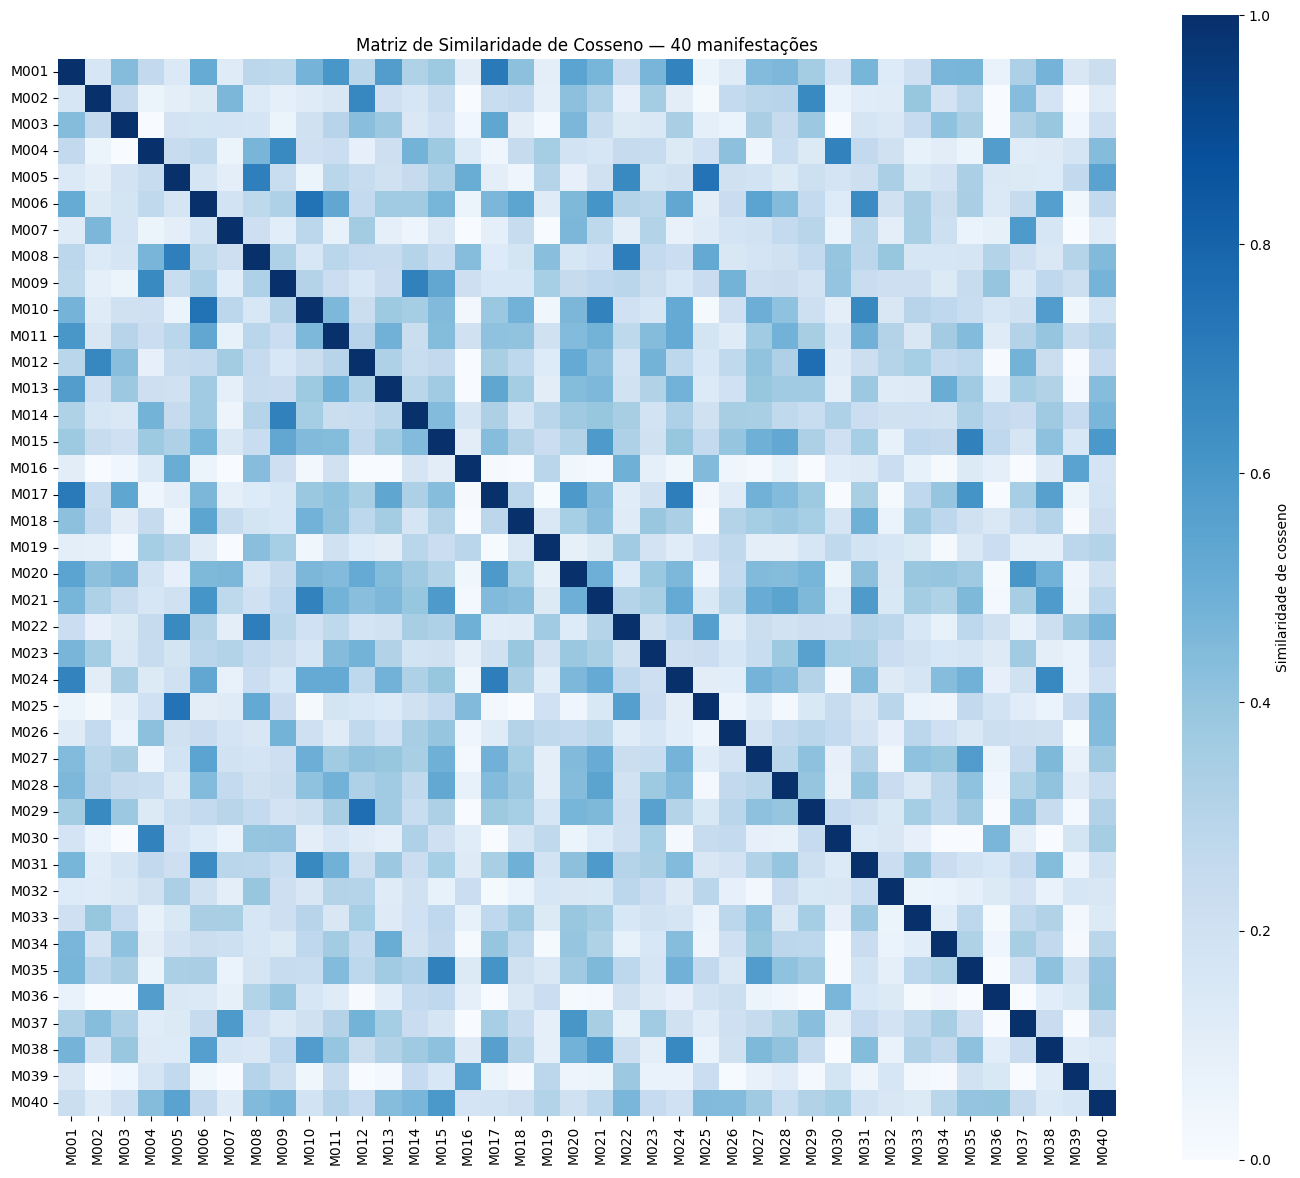

In [4]:
df_sim = pd.DataFrame(matriz_sim, index=ids, columns=ids)

plt.figure(figsize=(14, 12))
sns.heatmap(df_sim, cmap="Blues", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Similaridade de cosseno"})
plt.title(f"Matriz de Similaridade de Cosseno — {len(ids)} manifestações")
plt.tight_layout()
plt.savefig("matriz_similaridade.png", dpi=150)
plt.show()

## 5. Análise de Falsos Positivos e Falsos Negativos

O dataset sintético foi construído com um **gabarito conhecido** de duplicatas reais (ver `duplicatas_reais.json`), o que permite avaliar objetivamente a qualidade da detecção:

- **M003 × M017** — mesmo buraco/asfalto, descrito com palavras diferentes
- **M008 × M022** — mesma falta de médico, um usando o termo técnico "PSF"
- **M012 × M029** — mesmo descarte irregular de lixo em terreno baldio/vazio

In [5]:
with open("duplicatas_reais.json", encoding="utf-8") as f:
    duplicatas_reais = [tuple(p) for p in json.load(f)]

duplicatas_reais_set = {frozenset(p) for p in duplicatas_reais}
pares_detectados_set = {frozenset((p["id_1"], p["id_2"])) for p in pares_encontrados}

verdadeiros_positivos = duplicatas_reais_set & pares_detectados_set
falsos_negativos = duplicatas_reais_set - pares_detectados_set
falsos_positivos = pares_detectados_set - duplicatas_reais_set

print(f"Duplicatas reais no dataset: {len(duplicatas_reais_set)}")
print(f"Verdadeiros positivos (corretamente detectados): {len(verdadeiros_positivos)}")
for p in verdadeiros_positivos:
    print("   ", tuple(p))
print(f"\nFalsos negativos (duplicatas reais NÃO detectadas): {len(falsos_negativos)}")
for p in falsos_negativos:
    print("   ", tuple(p))
print(f"\nFalsos positivos (detectados mas não são duplicatas reais): {len(falsos_positivos)}")
for p in falsos_positivos:
    print("   ", tuple(p))

precisao = len(verdadeiros_positivos) / len(pares_detectados_set) if pares_detectados_set else float("nan")
cobertura = len(verdadeiros_positivos) / len(duplicatas_reais_set)
print(f"\nPrecisão: {precisao:.2%}" if pares_detectados_set else "\nPrecisão: N/A (nenhum par detectado)")
print(f"Cobertura (recall): {cobertura:.2%}")

Duplicatas reais no dataset: 3
Verdadeiros positivos (corretamente detectados): 1
    ('M012', 'M029')

Falsos negativos (duplicatas reais NÃO detectadas): 2
    ('M003', 'M017')
    ('M022', 'M008')

Falsos positivos (detectados mas não são duplicatas reais): 0

Precisão: 100.00%
Cobertura (recall): 33.33%


### Interpretação

Com o limiar ajustado para 0.75 (ver justificativa na seção 3), o sistema captura a duplicata mais evidente do gabarito (M012 × M029, similaridade 0.760) sem nenhum falso positivo. Isso mostra que um único limiar fixo não resolve bem todos os casos: valores baixos o suficiente para capturar M003×M017 (abaixo de ~0.55) introduzem falsos positivos vindos de manifestações apenas relacionadas por tema, não duplicadas de fato (ver seção 6). Na prática, esse tipo de sistema tende a rodar em dois estágios: um limiar mais alto/estrito para agrupamento automático, e uma faixa intermediária sinalizada para revisão humana em vez de decisão automática, em vez de um único valor fixo.

## 6. Teste com limiar alternativo (sensibilidade)

In [6]:
for limiar_teste in [0.70, 0.75, 0.80, 0.85, 0.90]:
    pares_t, _ = detectar_duplicatas(textos, limiar=limiar_teste, ids=ids, embeddings=embeddings)
    pares_t_set = {frozenset((p["id_1"], p["id_2"])) for p in pares_t}
    vp = len(duplicatas_reais_set & pares_t_set)
    fp = len(pares_t_set - duplicatas_reais_set)
    print(f"limiar={limiar_teste:.2f}  ->  {len(pares_t):3d} pares detectados "
          f"(verdadeiros positivos: {vp}/{len(duplicatas_reais_set)}, falsos positivos: {fp})")

limiar=0.70  ->    6 pares detectados (verdadeiros positivos: 2/3, falsos positivos: 4)
limiar=0.75  ->    1 pares detectados (verdadeiros positivos: 1/3, falsos positivos: 0)
limiar=0.80  ->    0 pares detectados (verdadeiros positivos: 0/3, falsos positivos: 0)
limiar=0.85  ->    0 pares detectados (verdadeiros positivos: 0/3, falsos positivos: 0)
limiar=0.90  ->    0 pares detectados (verdadeiros positivos: 0/3, falsos positivos: 0)
